# Sigmoid neuron with PyTorch

## Objective

Reproduce the NumPy sigmoid neuron with PyTorch and compare the forward pass, loss, gradients, parameter update, and trained model. The architecture is unchanged:

$$
\mathbf z=\mathbf X\mathbf w+b,
\qquad
\hat{\mathbf y}=\sigma(\mathbf z).
$$

We will use CPU tensors and 64-bit floating-point values so the numerical results can be compared directly with the NumPy implementation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch import nn

## OR training data

$$
y=x_1\lor x_2
$$

In [2]:
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=torch.float64, requires_grad=False)
y = torch.tensor([[0.0], [1.0], [1.0], [1.0]], dtype=torch.float64, requires_grad=False)

In [3]:
display(X)
print("")
display(y)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]], dtype=torch.float64)

tensor([[0.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

In [4]:
print(f"Shape: {X.shape}")
print(f"Dtype: {X.dtype}")
print(f"Device: {X.device}")

Shape: torch.Size([4, 2])
Dtype: torch.float64
Device: cpu


## Linear model

PyTorch's `nn.Linear` computes the logits

$$
\mathbf z=\mathbf X\mathbf W^{\mathsf T}+\mathbf b.
$$

For two inputs and one output, PyTorch stores $\mathbf W$ with shape $(1,2)$, the transpose of the $(2,1)$ weight vector used in the NumPy notebook.

In [5]:
linear = nn.Linear(in_features=2, out_features=1, bias=True, dtype=torch.float64)

with torch.no_grad():
    linear.weight.fill_(0.0)
    linear.bias.fill_(0.0)

In [6]:
display(linear.weight)
print("")
display(linear.bias)

Parameter containing:
tensor([[0., 0.]], dtype=torch.float64, requires_grad=True)

Parameter containing:
tensor([0.], dtype=torch.float64, requires_grad=True)

## Forward propagation and binary cross-entropy

$$
\mathbf z=\operatorname{Linear}(\mathbf X),
\qquad
\hat{\mathbf y}=\sigma(\mathbf z),
\qquad
J=\operatorname{BCEWithLogitsLoss}(\mathbf z,\mathbf y).
$$

`BCEWithLogitsLoss` combines sigmoid and binary cross-entropy in one numerically stable operation, so it receives raw logits rather than probabilities.

In [7]:
logits = linear(X)

display(logits)

tensor([[0.],
        [0.],
        [0.],
        [0.]], dtype=torch.float64, grad_fn=<AddmmBackward0>)

In [8]:
probabilities = torch.sigmoid(logits)

display(probabilities)

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], dtype=torch.float64, grad_fn=<SigmoidBackward0>)

In [9]:
loss_function = nn.BCEWithLogitsLoss()

loss = loss_function(logits, y)

display(loss)

tensor(0.6931, dtype=torch.float64,
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

## Automatic differentiation

Calling `loss.backward()` applies the chain rule through the recorded computation graph and stores each parameter gradient in its `.grad` attribute:

$$
\mathbf W.\mathrm{grad}=\frac{\partial J}{\partial\mathbf W},
\qquad
\mathbf b.\mathrm{grad}=\frac{\partial J}{\partial\mathbf b}.
$$

In [10]:
linear.zero_grad()

loss.backward()

In [11]:
display(linear.weight.grad)
print("")
display(linear.bias.grad)

tensor([[-0.2500, -0.2500]], dtype=torch.float64)

tensor([-0.2500], dtype=torch.float64)

## One optimizer step

PyTorch's SGD optimizer applies the same update used in the NumPy notebook:

$$
\boldsymbol\theta\leftarrow\boldsymbol\theta-\eta\nabla_{\boldsymbol\theta}J.
$$

In [12]:
optimizer = optim.SGD(linear.parameters(), lr=0.1)

optimizer.step()

In [13]:
display(linear.weight)
print("")
display(linear.bias)

Parameter containing:
tensor([[0.0250, 0.0250]], dtype=torch.float64, requires_grad=True)

Parameter containing:
tensor([0.0250], dtype=torch.float64, requires_grad=True)

In [14]:
with torch.no_grad():
    logits = linear(X)
    display(logits)
    print("")
    probabilities = torch.sigmoid(logits)
    display(probabilities)
    print("")
    loss = loss_function(logits, y)
    display(loss)

tensor([[0.0250],
        [0.0500],
        [0.0500],
        [0.0750]], dtype=torch.float64)

tensor([[0.5062],
        [0.5125],
        [0.5125],
        [0.5187]], dtype=torch.float64)

tensor(0.6747, dtype=torch.float64)

## Training loop

Each epoch clears the old gradients, performs a forward pass, backpropagates the loss, and updates the parameters:

$$
\texttt{zero\_grad}\;\longrightarrow\;\text{forward}\;\longrightarrow\;\text{loss}\;\longrightarrow\;\texttt{backward}\;\longrightarrow\;\texttt{step}.
$$

In [15]:
with torch.no_grad():
    linear.weight.fill_(0.0)
    linear.bias.fill_(0.0)

optimizer = optim.SGD(linear.parameters(), lr=0.1)
loss_history = []
epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = linear(X)

    loss = loss_function(logits, y)
    loss_history.append(loss.item())
    
    loss.backward()
    optimizer.step()

with torch.no_grad():
    display(linear.weight)
    display(linear.bias)
    print("")
    
    logits = linear(X)
    y_hat = torch.sigmoid(logits)
    display(y_hat)
    print("")

    predictions = torch.where(y_hat >= 0.5, 1, 0)
    display(predictions)
    print("")
    
    loss = loss_function(logits, y)
    display(loss)

Parameter containing:
tensor([[5.3605, 5.3605]], dtype=torch.float64, requires_grad=True)

Parameter containing:
tensor([-2.1836], dtype=torch.float64, requires_grad=True)

tensor([[0.1012],
        [0.9600],
        [0.9600],
        [0.9998]], dtype=torch.float64)

tensor([[0],
        [1],
        [1],
        [1]])

tensor(0.0472, dtype=torch.float64)

## Learning curve

Plot the stored scalar losses to verify that PyTorch follows the same optimization trajectory as the NumPy implementation.

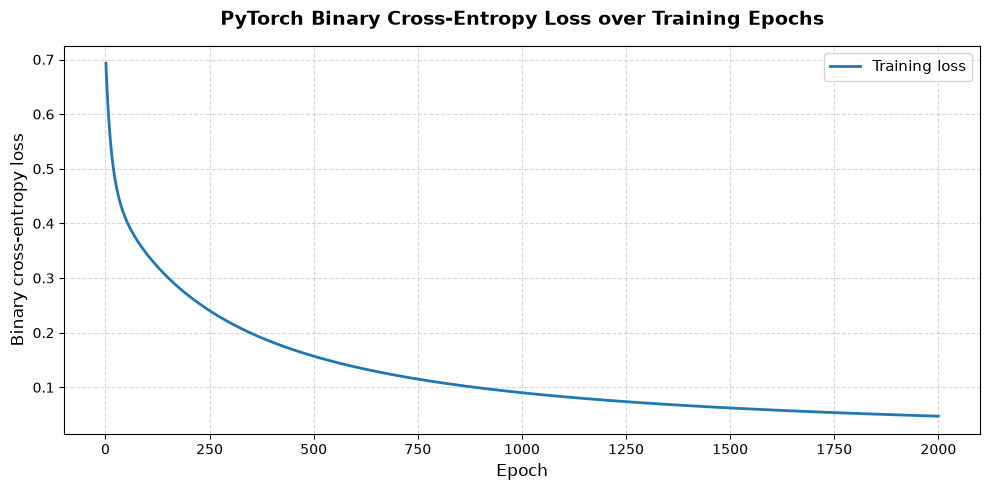

In [16]:
epoch_axis = range(1, len(loss_history) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_axis, loss_history, color="#1f77b4", linewidth=2, label="Training loss")
plt.title("PyTorch Binary Cross-Entropy Loss over Training Epochs", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary cross-entropy loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## NumPy and PyTorch comparison

Both notebooks implement the same model, loss, gradients, and SGD update. With identical initialization and hyperparameters, their first-step and final numerical results agree.

| Operation | NumPy implementation | PyTorch implementation |
| --- | --- | --- |
| Parameters | Explicit arrays | `nn.Parameter` objects inside `nn.Linear` |
| Forward pass | Explicit matrix operations and sigmoid | `nn.Linear` and `torch.sigmoid` |
| Loss | Manually coded BCE | `nn.BCEWithLogitsLoss` |
| Gradients | Analytical formulas | `loss.backward()` |
| Update | Explicit subtraction | `optim.SGD.step()` |

PyTorch automates differentiation and parameter management; it does not change the mathematics of the model.